In [29]:
#Importing relevant Python libraries

import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error

In [8]:
#Reading the dataset
df = pd.read_csv('critical_temperature.csv')
df.head()

,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


In [5]:
#Summary Statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
number_of_elements,21263.0,4.115224,1.439295,1.000000,3.000000,4.000000,5.000000,9.0000
mean_atomic_mass,21263.0,87.557631,29.676497,6.941000,72.458076,84.922750,100.404410,208.9804
wtd_mean_atomic_mass,21263.0,72.988310,33.490406,6.423452,52.143839,60.696571,86.103540,208.9804
gmean_atomic_mass,21263.0,71.290627,31.030272,5.320573,58.041225,66.361592,78.116681,208.9804
wtd_gmean_atomic_mass,21263.0,58.539916,36.651067,1.960849,35.248990,39.918385,73.113234,208.9804
...,...,...,...,...,...,...,...,...
range_Valence,21263.0,2.041010,1.242345,0.000000,1.000000,2.000000,3.000000,6.0000
wtd_range_Valence,21263.0,1.483007,0.978176,0.000000,0.921454,1.063077,1.918400,6.9922
std_Valence,21263.0,0.839342,0.484676,0.000000,0.451754,0.800000,1.200000,3.0000
wtd_std_Valence,21263.0,0.673987,0.455580,0.000000,0.306892,0.500000,1.020436,3.0000


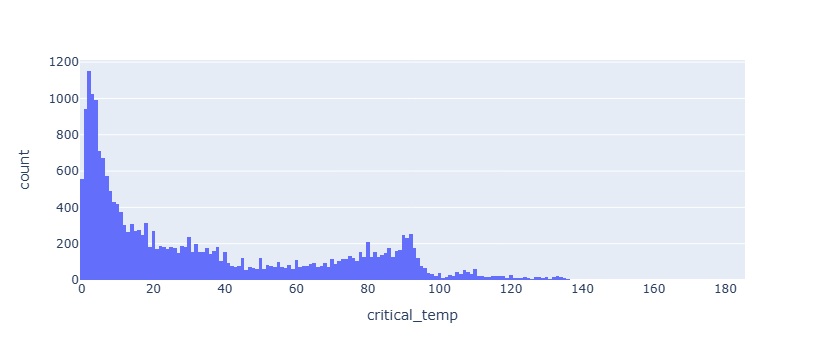

In [6]:
#Histogram to show critical temperature distribution (split into 300 intervals)
fig = px.histogram(df, x='critical_temp', nbins=300)
fig.show()
fig.write_image("plots/critical_temp_distribution.png")

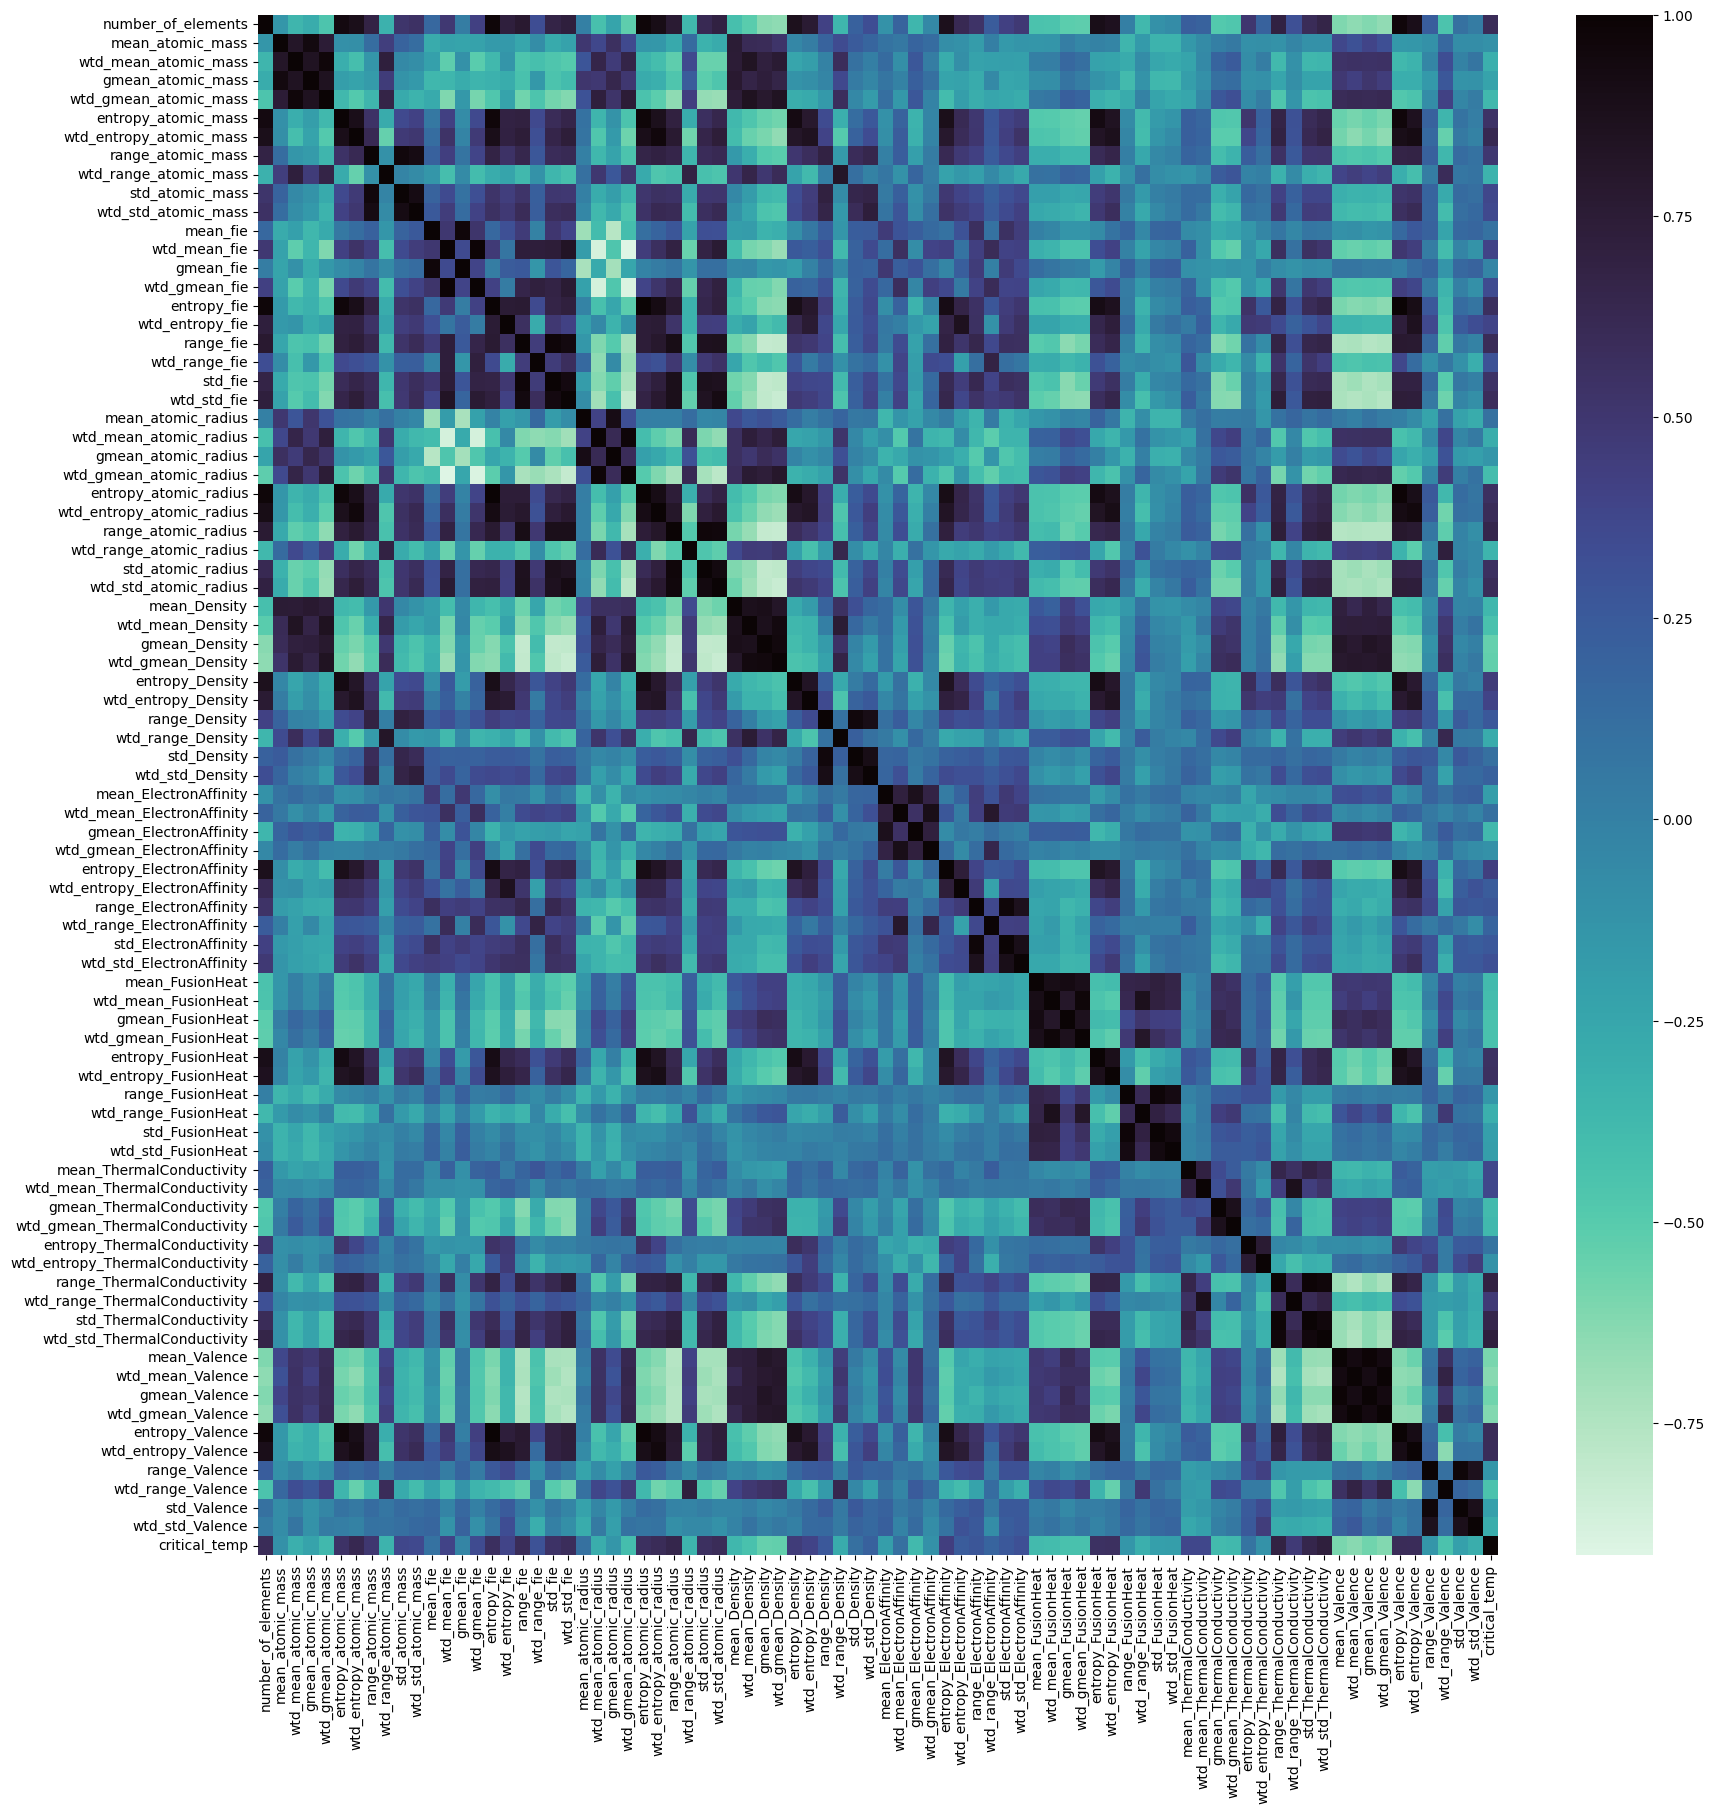

In [15]:
#Correlation heatmap
corr = df.corr()
plt.figure(figsize=(20,20))
sns.heatmap(corr, cmap='mako_r', annot=False)
plt.savefig("plots/correlation_heatmap.png")
plt.show()

In [16]:
#Convert to absolute value of correlation
cor_target = abs(corr["critical_temp"])
#Set threshold of absolute correlation to 0.2
relevant_features = cor_target[cor_target > 0.2]
#Creating a variable that includes all the variables
names = [index for index, value in relevant_features.items()]
#Removing our 'y' value
names.remove('critical_temp')
#Checking if it is correct now
print(names)

['number_of_elements', 'wtd_mean_atomic_mass', 'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass', 'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass', 'std_atomic_mass', 'wtd_std_atomic_mass', 'wtd_mean_fie', 'wtd_gmean_fie', 'entropy_fie', 'wtd_entropy_fie', 'range_fie', 'wtd_range_fie', 'std_fie', 'wtd_std_fie', 'wtd_mean_atomic_radius', 'wtd_gmean_atomic_radius', 'entropy_atomic_radius', 'wtd_entropy_atomic_radius', 'range_atomic_radius', 'wtd_range_atomic_radius', 'std_atomic_radius', 'wtd_std_atomic_radius', 'mean_Density', 'wtd_mean_Density', 'gmean_Density', 'wtd_gmean_Density', 'entropy_Density', 'wtd_entropy_Density', 'range_Density', 'wtd_range_Density', 'wtd_std_Density', 'gmean_ElectronAffinity', 'entropy_ElectronAffinity', 'wtd_entropy_ElectronAffinity', 'range_ElectronAffinity', 'std_ElectronAffinity', 'wtd_std_ElectronAffinity', 'mean_FusionHeat', 'wtd_mean_FusionHeat', 'gmean_FusionHeat', 'wtd_gmean_FusionHeat', 'entropy_FusionHeat'

In [17]:
X = df[names]
y = df['critical_temp']

In [18]:
#Splitting the training and testing periods. Using 70% of the data to train the model, testing on the remaining 30%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42) 

In [19]:
#Scaling the variables to a standard scaler
scaler = StandardScaler()
#Fit it to the training data only, not testing data
scaler.fit(X_train)
#Transforming the training and testing data
X_train = scaler.transform(X_train)
X_test = scaler.transform(X_test) 

In [23]:
#Using a Linear Regression Model
model = LinearRegression()

In [24]:
#Training the model with the training data
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [25]:
#Calculating the predictions
predictions = model.predict(X_test)

In [28]:
#Computing R^2 metric
r2 = r2_score(y_test, predictions)
print("R²:", r2)

R²: 0.7172201487253662


In [30]:
#Computing RMSE metric
rmse = root_mean_squared_error(y_test, predictions)
print("RMSE:", rmse)

RMSE: 18.116879846522007


In [31]:
#Computing MAE metric
mae = mean_absolute_error(y_test, predictions)
print("MAE:", mae)

MAE: 13.805218351448813


In [34]:
#Coefficients
coefficients = model.coef_

# Put the features and their coefficients into a DataFrame
feature_importance = pd.DataFrame({
    'Feature': names,
    'Coefficient': coefficients,
    'Absolute_Coefficient': np.abs(coefficients)
})

# sorting by Absolute Coefficient (which features have the biggest impact)
feature_importance = feature_importance.sort_values(
    by='Absolute_Coefficient',
    ascending=False
)

print(feature_importance.to_string(index=False))

                      Feature  Coefficient  Absolute_Coefficient
      wtd_gmean_atomic_radius   -73.480242             73.480242
       wtd_mean_atomic_radius    61.811520             61.811520
 wtd_mean_ThermalConductivity    32.285147             32.285147
          wtd_entropy_Valence   -30.781912             30.781912
                    range_fie    24.090393             24.090393
            wtd_gmean_Density    22.302553             22.302553
              wtd_entropy_fie    21.612309             21.612309
         std_ElectronAffinity    21.211661             21.211661
                gmean_Valence    21.171936             21.171936
wtd_gmean_ThermalConductivity   -21.046629             21.046629
      std_ThermalConductivity    20.964593             20.964593
       range_ElectronAffinity   -19.017797             19.017797
          wtd_mean_FusionHeat   -16.958209             16.958209
    range_ThermalConductivity   -16.151759             16.151759
            std_atomic_ra

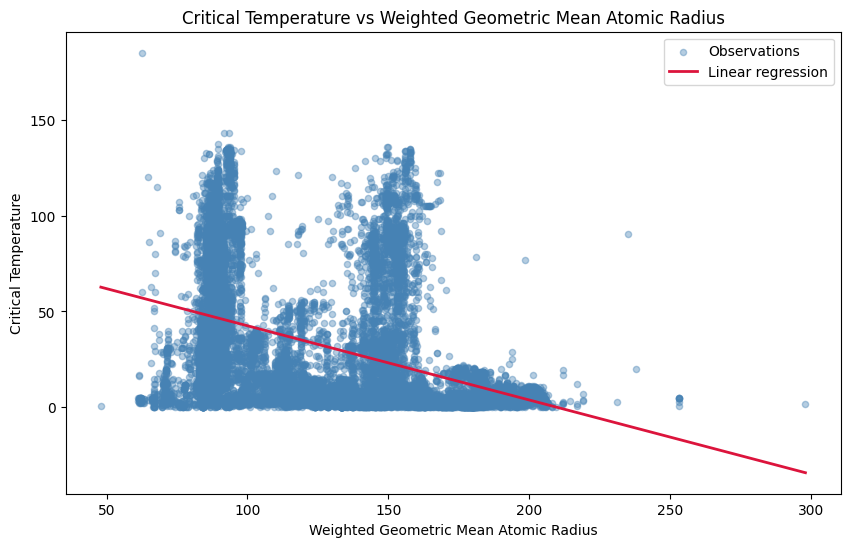

In [45]:
# Plot weighted geometric mean atomic radius against critical temperature
feature = 'wtd_gmean_atomic_radius'
X = df[feature]
y = df['critical_temp']

# Fit a simple linear regression
model_plot = LinearRegression()
model_plot.fit(X.values.reshape(-1, 1), y)

# Predictions
y_pred = model_plot.predict(X.values.reshape(-1, 1))

# Sort x values so the regression line is drawn properly
sort_idx = np.argsort(X)

# Create plot
plt.figure(figsize=(10, 6))

# Scatter points
plt.scatter(
    X,
    y,
    alpha=0.4,
    s=20,
    color='steelblue',
    label='Observations'
)

# Regression line
plt.plot(
    X.iloc[sort_idx],
    y_pred[sort_idx],
    color='crimson',
    linewidth=2,
    label='Linear regression'
)

plt.xlabel('Weighted Geometric Mean Atomic Radius')
plt.ylabel('Critical Temperature')
plt.title('Critical Temperature vs Weighted Geometric Mean Atomic Radius')
plt.legend()

# Save to plots subfolder
plt.savefig(
    'plots/critical_temp_vs_wtd_gmean_atomic_radius.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()